# Solve a 2D Poisson BVP with the Direct BSPF Sylvester Solver

This notebook demonstrates the direct tensor-product Poisson solver
`Poisson2DDirichletSolver` for the boundary-value problem

$$
-\Delta u = f \quad \text{in } [0, 1]^2, \qquad u = g \quad \text{on } \partial\Omega.
$$

We use a manufactured solution so the right-hand side and the exact answer
are both known analytically, including a nonzero nonuniform Dirichlet boundary.


## Environment Setup

The next cell makes the notebook runnable directly from the repository root
or from inside the `examples/` tree without requiring `pybspf` to be
installed into the active Python environment.


In [76]:
from pathlib import Path
import sys

cwd = Path.cwd().resolve()
REPO_ROOT = next((parent for parent in (cwd, *cwd.parents) if (parent / "pyproject.toml").exists()), cwd)
SRC_ROOT = REPO_ROOT / "src"

for candidate in (SRC_ROOT, REPO_ROOT):
    candidate_str = str(candidate)
    if candidate_str not in sys.path:
        sys.path.insert(0, candidate_str)

REPO_ROOT


PosixPath('/Users/moulin/Workspace/pybspf')

## Imports

We use NumPy for the manufactured solution, Matplotlib for visualization,
and the package-level direct Poisson solver from `pybspf`.


In [77]:
import numpy as np
import matplotlib.pyplot as plt

from pybspf import Poisson2DDirichletSolver


## Manufactured Solution

We choose a shifted Gaussian

$$
u_{\mathrm{ex}}(x, y) = \exp\bigl(-\alpha((x-x_0)^2 + (y-y_0)^2)\bigr),
$$

with the center shifted away from the middle of the square so the Dirichlet
boundary data are nonzero and nonuniform on all four edges. For this choice,

$$
-\Delta u_{\mathrm{ex}} = 4\alpha\left(1 - \alpha\bigl((x-x_0)^2 + (y-y_0)^2\bigr)\right)u_{\mathrm{ex}}.
$$


In [78]:
x = np.linspace(0.0, 1.0, 512)
y = np.linspace(0.0, 1.0, 512)
xx, yy = np.meshgrid(x, y)

alpha = 18.0
x0 = 0.43
y0 = 0.58

r2 = (xx - x0) ** 2 + (yy - y0) ** 2
alpha = 10
u_exact = np.sin(alpha*xx)*np.sin(alpha*yy)
rhs = 2*alpha**2*np.sin(alpha*xx)*np.sin(alpha*yy) 

solver = Poisson2DDirichletSolver.from_grids(
    x=x,
    y=y,
    degree_x=7,
    degree_y=7,
    n_basis_x=50,
    n_basis_y=50,
    use_clustering_x=True,
    use_clustering_y=True,
    clustering_factor_x=2.0,
    clustering_factor_y=2.0,
)

u_num = solver.solve_hybrid_dst(
    rhs,
    left=u_exact[:, 0],
    right=u_exact[:, -1],
    bottom=u_exact[0, :],
    top=u_exact[-1, :],
)
error = u_num - u_exact


## Diagnostics

We report the maximum boundary mismatch against the prescribed nonzero traces,
together with interior `L2` and
`L∞` errors against the manufactured solution.


In [79]:
boundary_max = max(
    np.max(np.abs(u_num[0, :] - u_exact[0, :])),
    np.max(np.abs(u_num[-1, :] - u_exact[-1, :])),
    np.max(np.abs(u_num[:, 0] - u_exact[:, 0])),
    np.max(np.abs(u_num[:, -1] - u_exact[:, -1])),
)

interior = (slice(4, -4), slice(4, -4))
l2_error = np.sqrt(np.mean(error[interior] ** 2))
linf_error = np.max(np.abs(error[interior]))

print(f"Boundary max error : {boundary_max:.3e}")
print(f"Interior L2 error  : {l2_error:.3e}")
print(f"Interior Linf error: {linf_error:.3e}")


Boundary max error : 1.687e-09
Interior L2 error  : 1.650e-05
Interior Linf error: 3.715e-05


## Convergence Study

To study convergence on the same smooth inhomogeneous-boundary problem, we
repeat the shifted Gaussian manufactured solution on a sequence of grids and
track the interior `L2` and `L∞` errors.

Because the center is shifted away from the domain midpoint, all four edges
carry nonzero, nonuniform Dirichlet data.


In [86]:
# resolutions = [32,64,128,256,512]
resolutions = np.geomspace(100, 1000, 20).astype(int)
l2_errors = []
linf_errors = []
spacings = []

for n in resolutions:
    x_n = np.linspace(0.0, 1.0, n)
    y_n = np.linspace(0.0, 1.0, n)
    xx_n, yy_n = np.meshgrid(x_n, y_n)

    u_exact_n =  np.sin(alpha*xx_n)*np.sin(alpha*yy_n)
    rhs_n =  2*alpha**2*np.sin(alpha*xx_n)*np.sin(alpha*yy_n) 

    solver_n = Poisson2DDirichletSolver.from_grids(
        x=x_n,
        y=y_n,
        degree_x=7,
        degree_y=7,
        n_basis_x=50,
        n_basis_y=50
    )

    u_num_n = solver_n.solve(
        rhs_n,
        left=u_exact_n[:, 0],
        right=u_exact_n[:, -1],
        bottom=u_exact_n[0, :],
        top=u_exact_n[-1, :],
    )

    error_n = u_num_n - u_exact_n
    interior_n = (slice(4, -4), slice(4, -4))
    l2_errors.append(np.sqrt(np.mean(error_n[interior_n] ** 2)))
    linf_errors.append(np.max(np.abs(error_n[interior_n])))
    spacings.append(x_n[1] - x_n[0])
    print(linf_errors)

spacings = np.asarray(spacings)
l2_errors = np.asarray(l2_errors)
linf_errors = np.asarray(linf_errors)

l2_rate, l2_offset = np.polyfit(np.log(spacings), np.log(l2_errors), 1)
linf_rate, linf_offset = np.polyfit(np.log(spacings), np.log(linf_errors), 1)
l2_fit = np.exp(l2_offset) * spacings ** l2_rate
linf_fit = np.exp(linf_offset) * spacings ** linf_rate

for n, h, l2, linf in zip(resolutions, spacings, l2_errors, linf_errors):
    print(f"n={n:4d}, h={h:.6f}, L2={l2:.3e}, Linf={linf:.3e}")

print(f"\nFitted L2 convergence rate  : {l2_rate:.3f}")
print(f"Fitted Linf convergence rate: {linf_rate:.3f}")


[np.float64(0.0004147550138787759)]
[np.float64(0.0004147550138787759), np.float64(0.00031315048084426533)]
[np.float64(0.0004147550138787759), np.float64(0.00031315048084426533), np.float64(0.00021388330409830014)]
[np.float64(0.0004147550138787759), np.float64(0.00031315048084426533), np.float64(0.00021388330409830014), np.float64(0.00011144590287892608)]
[np.float64(0.0004147550138787759), np.float64(0.00031315048084426533), np.float64(0.00021388330409830014), np.float64(0.00011144590287892608), np.float64(6.108043990968315e-05)]
[np.float64(0.0004147550138787759), np.float64(0.00031315048084426533), np.float64(0.00021388330409830014), np.float64(0.00011144590287892608), np.float64(6.108043990968315e-05), np.float64(3.264633182120669e-05)]
[np.float64(0.0004147550138787759), np.float64(0.00031315048084426533), np.float64(0.00021388330409830014), np.float64(0.00011144590287892608), np.float64(6.108043990968315e-05), np.float64(3.264633182120669e-05), np.float64(1.3032996777628814e-05

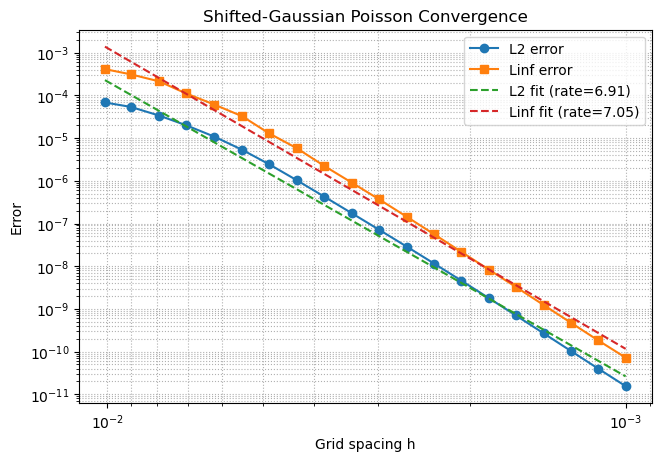

In [87]:
fig, ax = plt.subplots(figsize=(6.5, 4.5), constrained_layout=True)
ax.loglog(spacings, l2_errors, "o-", label="L2 error")
ax.loglog(spacings, linf_errors, "s-", label="Linf error")
ax.loglog(spacings, l2_fit, "--", label=f"L2 fit (rate={l2_rate:.2f})")
ax.loglog(spacings, linf_fit, "--", label=f"Linf fit (rate={linf_rate:.2f})")
ax.invert_xaxis()
ax.set_xlabel("Grid spacing h")
ax.set_ylabel("Error")
ax.set_title("Shifted-Gaussian Poisson Convergence")
ax.grid(True, which="both", ls=":")
ax.legend()
plt.show()


## Visualization

The next cell plots the numerical solution, the exact solution, and the pointwise error.


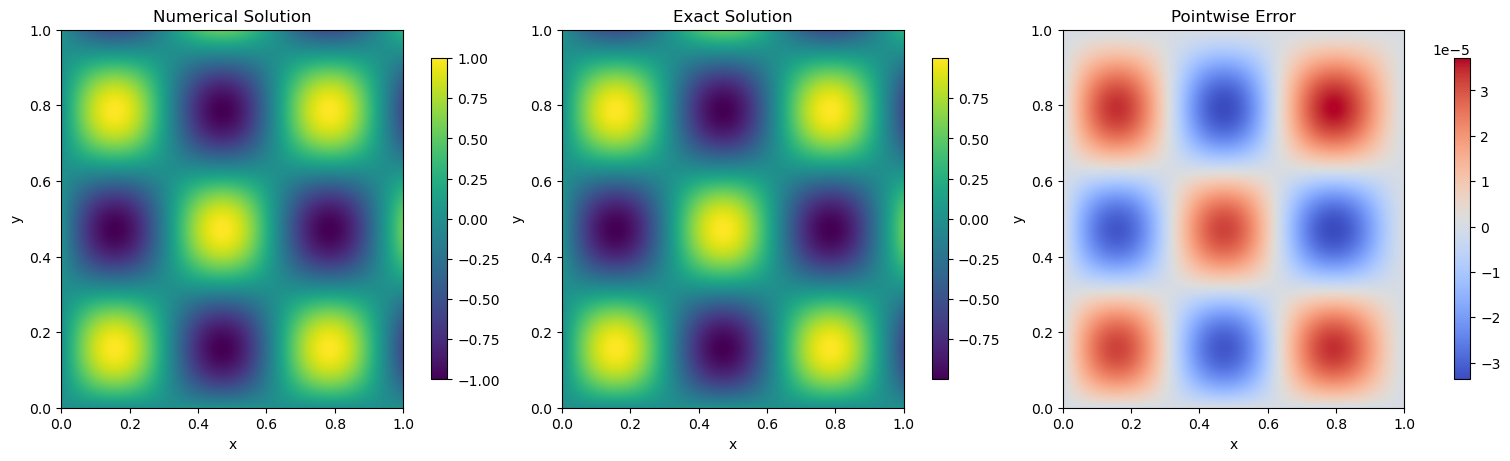

In [82]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), constrained_layout=True)
extent = [x[0], x[-1], y[0], y[-1]]

im0 = axes[0].imshow(u_num, origin="lower", extent=extent, aspect="auto")
axes[0].set_title("Numerical Solution")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")

im1 = axes[1].imshow(u_exact, origin="lower", extent=extent, aspect="auto")
axes[1].set_title("Exact Solution")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")

im2 = axes[2].imshow(error, origin="lower", extent=extent, aspect="auto", cmap="coolwarm")
axes[2].set_title("Pointwise Error")
axes[2].set_xlabel("x")
axes[2].set_ylabel("y")

fig.colorbar(im0, ax=axes[0], shrink=0.85)
fig.colorbar(im1, ax=axes[1], shrink=0.85)
fig.colorbar(im2, ax=axes[2], shrink=0.85)
plt.show()
